In [11]:
import pandas as pd

In [12]:
df=pd.read_csv("data/ETH_1h.csv",parse_dates=["Date"],date_format="%Y-%m-%d %I-%p")
#Converted data column type strıng to date

In [13]:
pd.set_option("display.max_row",10)
pd.set_option("display.min_row",10)

In [14]:
df.loc[0:10,"Date"].dt.day_name()

0     Friday
1     Friday
2     Friday
3     Friday
4     Friday
       ...  
6     Friday
7     Friday
8     Friday
9     Friday
10    Friday
Name: Date, Length: 11, dtype: str

In [15]:
df["DayOfWeek"]=df["Date"].dt.day_name()

In [16]:
df["Date"].min()

Timestamp('2017-07-01 11:00:00')

In [17]:
df["Date"].max()-df["Date"].min()

Timedelta('986 days 09:00:00')

In [18]:
filt= ( df["Date"].dt.year == 2017)
filt2= ( (df["Date"] >="2019-01-01") & (df["Date"] <"2020-01-28"))

In [19]:
df.loc[filt2]

,Date,Symbol,Open,High,Low,Close,Volume,DayOfWeek
1101,2020-01-27 23:00:00,ETHUSD,169.85,170.46,169.46,169.77,425754.15,Monday
1102,2020-01-27 22:00:00,ETHUSD,171.08,171.08,169.22,169.85,518202.09,Monday
1103,2020-01-27 21:00:00,ETHUSD,171.57,171.70,170.04,171.08,660705.53,Monday
1104,2020-01-27 20:00:00,ETHUSD,170.81,171.63,170.56,171.57,700154.11,Monday
1105,2020-01-27 19:00:00,ETHUSD,170.94,171.24,169.96,170.81,1378998.99,Monday
...,...,...,...,...,...,...,...,...
10504,2019-01-01 04:00:00,ETHUSD,130.75,133.96,130.74,131.96,2791135.37,Tuesday
10505,2019-01-01 03:00:00,ETHUSD,130.06,130.79,130.06,130.75,503732.63,Tuesday
10506,2019-01-01 02:00:00,ETHUSD,130.79,130.88,129.55,130.06,838183.43,Tuesday
10507,2019-01-01 01:00:00,ETHUSD,131.62,131.62,130.77,130.79,434917.99,Tuesday


In [20]:
df.set_index("Date",inplace=True)
df.sort_index(inplace=True)

In [21]:
df.loc["2020-01-01","High"].max()

np.float64(132.68)

In [22]:
df["High"].resample("W").max()     ###INcrebadle Method Use fucking this

Date
2017-07-02    293.73
2017-07-09    285.00
2017-07-16    240.33
2017-07-23    249.40
2017-07-30    229.99
               ...  
2020-02-16    290.00
2020-02-23    287.13
2020-03-01    278.13
2020-03-08    253.01
2020-03-15    208.65
Freq: W-SUN, Name: High, Length: 142, dtype: float64

In [23]:
high=df["High"].resample("D").max()

In [24]:
high["2020-01-01"]

np.float64(132.68)

In [25]:
%matplotlib inline

<Axes: xlabel='Date'>

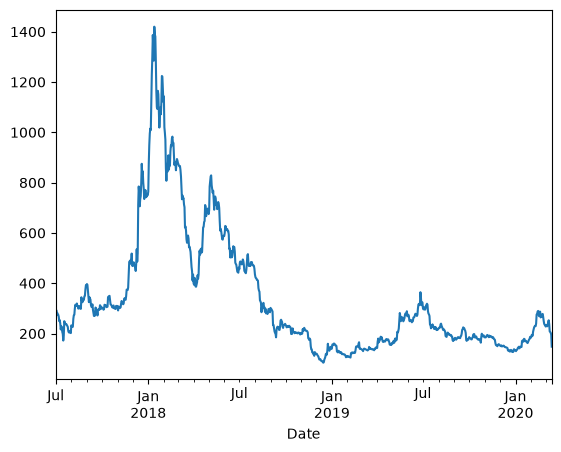

In [26]:
high.plot()

In [17]:
df.resample("W").min()

,Symbol,Open,High,Low,Close,Volume,DayOfWeek
Date,,,,,,,
2017-07-02,ETHUSD,256.81,257.92,253.23,256.81,573434.18,Saturday
2017-07-09,ETHUSD,233.45,234.00,231.25,233.45,138947.87,Friday
2017-07-16,ETHUSD,134.32,141.70,130.26,134.32,229799.27,Friday
2017-07-23,ETHUSD,155.68,159.54,153.25,159.53,310988.93,Friday
2017-07-30,ETHUSD,180.00,181.80,178.03,180.00,241425.61,Friday
...,...,...,...,...,...,...,...
2020-02-16,ETHUSD,218.32,219.63,216.31,218.32,411744.02,Friday
2020-02-23,ETHUSD,245.78,249.79,242.36,245.78,333556.99,Friday
2020-03-01,ETHUSD,212.50,214.79,209.26,212.50,222951.78,Friday


In [27]:
arda=df.resample("W").agg({"Close":"mean","High":"max","Low":"min","Volume":"sum"})
arda

,Close,High,Low,Volume
Date,,,,
2017-07-02,268.202162,293.73,253.23,8.084631e+07
2017-07-09,261.062083,285.00,231.25,2.246746e+08
2017-07-16,195.698393,240.33,130.26,5.017750e+08
2017-07-23,212.783750,249.40,153.25,7.221637e+08
2017-07-30,203.309524,229.99,178.03,2.657305e+08
...,...,...,...,...
2020-02-16,255.198452,290.00,216.31,3.912867e+08
2020-02-23,265.321905,287.13,242.36,3.067838e+08
2020-03-01,236.373988,278.13,209.26,3.693920e+08


<Axes: xlabel='Date'>

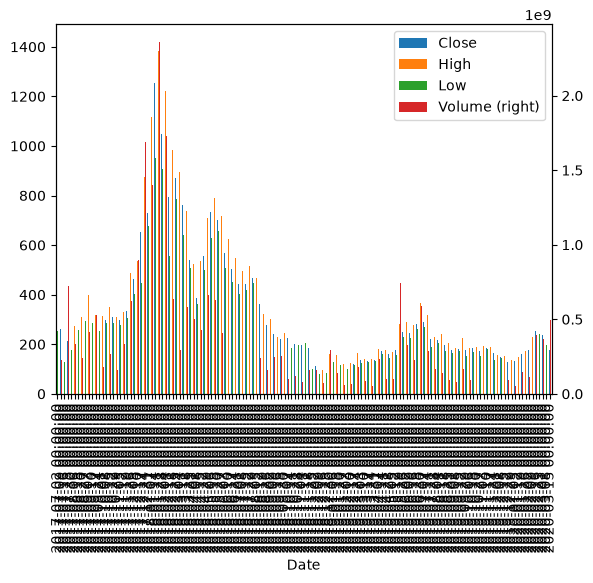

In [29]:
arda.plot(secondary_y=["Volume"],kind="bar")